In [1]:
import argparse
from guacamol.benchmark_suites import distribution_learning_suite_v1
from guacamol.distribution_matching_generator import DistributionMatchingGenerator

In [2]:
class MyModelWrapper(DistributionMatchingGenerator):
    def __init__(self, my_model, data):
        self.model = my_model
        self.data = data
        self.counter = 0

    def generate(self, number_samples):
        to_return = self.data[self.counter : self.counter + number_samples]
        self.counter += number_samples
        #print("counter is ", self.counter)
        return to_return

def run_benchmarks(chembl_path, llama_smiles_path, num_samples=10000):
    benchmark_list = distribution_learning_suite_v1(chembl_path, number_samples=num_samples)

    with open(llama_smiles_path, "r") as f:
        llama31_smiles_all = f.read().split("\n")

    
    
    to_test = MyModelWrapper([], llama31_smiles_all)
    results = []
    for i, benchmark in enumerate(benchmark_list):
        result = benchmark.assess_model(to_test)
        results.append(result)
        print(result.benchmark_name, result.score)
    return results


In [3]:
chembl_path = 'chembl_random_smiles.txt'
num_samples=10000


benchmark_list = distribution_learning_suite_v1(chembl_path, number_samples=num_samples)

In [4]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

# Initialize lists to store results
temperatures = [round(0.1*x, 1) for x in range(5, 15)]
validities_all = []
uniquenesses_all = []
novelties_all = []
klds_all = []
fcds_all = []

# Number of runs for each temperature
n_runs = 3

for t in tqdm(temperatures):
    print(f"Processing temperature {t}...")
    
    # Initialize lists for this temperature
    temp_validities = []
    temp_uniquenesses = []
    temp_novelties = []
    temp_klds = []
    temp_fcds = []

    # Read the file
    with open(f'8b-lora32/samples/temp{t}.txt', "r") as f:
        smiles = f.read().split("\n")

    to_test = MyModelWrapper([], smiles)
    
    # Run benchmark n_runs times for each temperature
    for run in range(n_runs):
        print(f"  Run {run + 1}/{n_runs}")
        
        results = []
        for i, benchmark in enumerate(benchmark_list):
            result = benchmark.assess_model(to_test)
            results.append(result)
        
        # Store results for this run
        temp_validities.append(results[0].score)
        temp_uniquenesses.append(results[1].score)
        temp_novelties.append(results[2].score)
        temp_klds.append(results[3].score)
        temp_fcds.append(results[4].score)
    
    # Store all runs for this temperature
    validities_all.append(temp_validities)
    uniquenesses_all.append(temp_uniquenesses)
    novelties_all.append(temp_novelties)
    klds_all.append(temp_klds)
    fcds_all.append(temp_fcds)

# Convert to numpy arrays for easier calculation
validities_all = np.array(validities_all)
uniquenesses_all = np.array(uniquenesses_all)
novelties_all = np.array(novelties_all)
klds_all = np.array(klds_all)
fcds_all = np.array(fcds_all)

# Calculate means and standard errors
validities_mean = np.mean(validities_all, axis=1)
validities_se = np.std(validities_all, axis=1) / np.sqrt(n_runs)

uniquenesses_mean = np.mean(uniquenesses_all, axis=1)
uniquenesses_se = np.std(uniquenesses_all, axis=1) / np.sqrt(n_runs)

novelties_mean = np.mean(novelties_all, axis=1)
novelties_se = np.std(novelties_all, axis=1) / np.sqrt(n_runs)

klds_mean = np.mean(klds_all, axis=1)
klds_se = np.std(klds_all, axis=1) / np.sqrt(n_runs)

fcds_mean = np.mean(fcds_all, axis=1)
fcds_se = np.std(fcds_all, axis=1) / np.sqrt(n_runs)


  0%|          | 0/10 [00:00<?, ?it/s]

Processing temperature 0.5...
  Run 1/3


/path/to/conda/envs/mol-benchmark/lib/python3.8/site-packages/fcd/fcd.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_config = torch.load(model_path)


  Run 2/3
  Run 3/3


 10%|█         | 1/10 [04:28<40:20, 268.97s/it]

...

 80%|████████  | 8/10 [32:55<08:12, 246.11s/it]

Processing temperature 1.3...
  Run 1/3
  Run 2/3
  Run 3/3


 90%|█████████ | 9/10 [37:03<04:06, 246.65s/it]

Processing temperature 1.4...
  Run 1/3
  Run 2/3
  Run 3/3


100%|██████████| 10/10 [41:20<00:00, 248.09s/it]


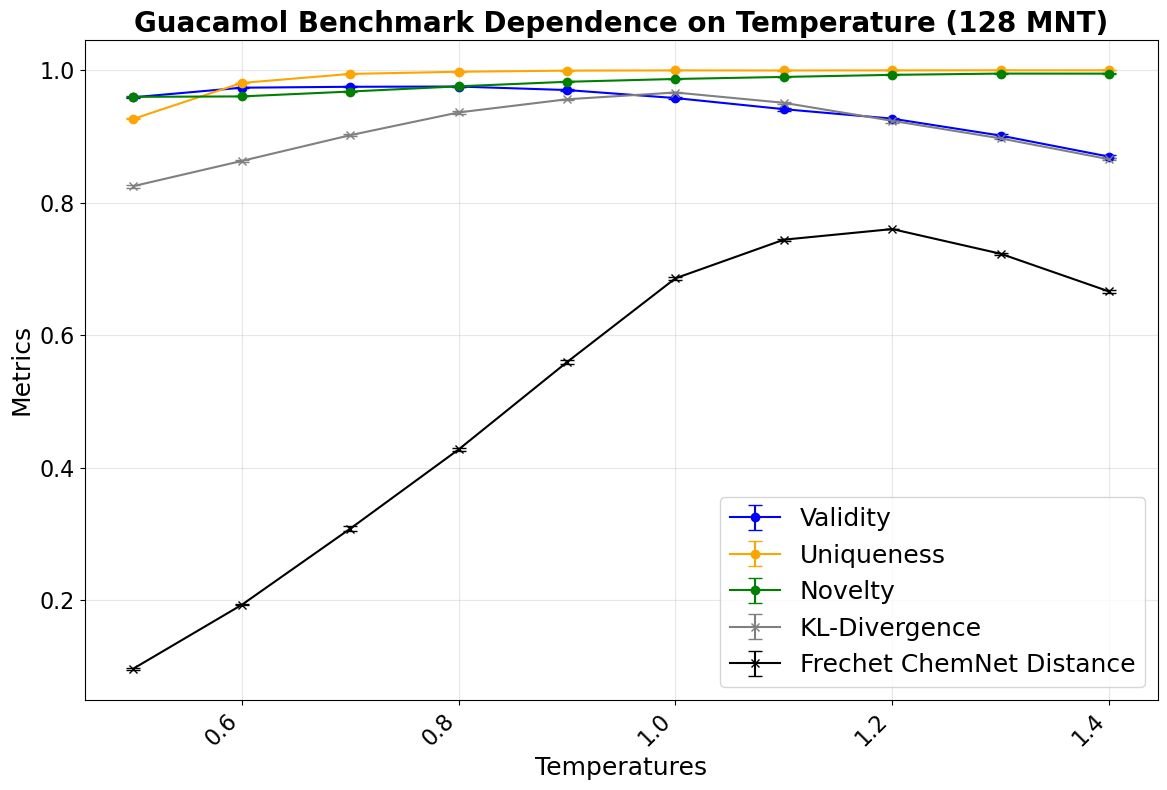


Summary Statistics:

Temperature 0.5:
  Validity: 0.9593 ± 0.0005
  Uniqueness: 0.9267 ± 0.0009
  Novelty: 0.9599 ± 0.0006
  KL-Divergence: 0.8252 ± 0.0025
  Frechet ChemNet Distance: 0.0970 ± 0.0014

Temperature 0.6:
  Validity: 0.9737 ± 0.0003
  Uniqueness: 0.9809 ± 0.0006
  Novelty: 0.9606 ± 0.0001
  KL-Divergence: 0.8632 ± 0.0017
  Frechet ChemNet Distance: 0.1933 ± 0.0009

Temperature 0.7:
  Validity: 0.9751 ± 0.0008
  Uniqueness: 0.9945 ± 0.0001
  Novelty: 0.9679 ± 0.0011
  KL-Divergence: 0.9021 ± 0.0013
  Frechet ChemNet Distance: 0.3082 ± 0.0034

Temperature 0.8:
  Validity: 0.9755 ± 0.0002
  Uniqueness: 0.9978 ± 0.0002
  Novelty: 0.9758 ± 0.0009
  KL-Divergence: 0.9364 ± 0.0018
  Frechet ChemNet Distance: 0.4278 ± 0.0027

Temperature 0.9:
  Validity: 0.9702 ± 0.0013
  Uniqueness: 0.9995 ± 0.0000
  Novelty: 0.9827 ± 0.0005
  KL-Divergence: 0.9563 ± 0.0007
  Frechet ChemNet Distance: 0.5596 ± 0.0026

Temperature 1.0:
  Validity: 0.9581 ± 0.0013
  Uniqueness: 0.9998 ± 0.0000
  N

In [ ]:
# Create the plot with error bars
plt.figure(figsize=(12, 8))

# Plot each metric with error bars
plt.errorbar(temperatures, validities_mean, yerr=validities_se, 
             label='Validity', color='blue', marker='o', capsize=5)
plt.errorbar(temperatures, uniquenesses_mean, yerr=uniquenesses_se, 
             label='Uniqueness', color='orange', marker='o', capsize=5)
plt.errorbar(temperatures, novelties_mean, yerr=novelties_se, 
             label='Novelty', color='green', marker='o', capsize=5)
plt.errorbar(temperatures, klds_mean, yerr=klds_se, 
             label='KL-Divergence', color='grey', marker='x', capsize=5)
plt.errorbar(temperatures, fcds_mean, yerr=fcds_se, 
             label='Frechet ChemNet Distance', color='black', marker='x', capsize=5)
# Add labels and title
plt.xlabel('Temperatures', fontsize=18)
plt.ylabel('Metrics', fontsize=18)
plt.title(f'Guacamol Benchmark Dependence on Temperature', fontsize=20, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)

# Add a legend to identify the metrics
plt.legend(fontsize=18)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.savefig('guac_temp_dependence_with_errors_128mnt.png', dpi=600, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("=" * 50)
for i, temp in enumerate(temperatures):
    print(f"\nTemperature {temp}:")
    print(f"  Validity: {validities_mean[i]:.4f} ± {validities_se[i]:.4f}")
    print(f"  Uniqueness: {uniquenesses_mean[i]:.4f} ± {uniquenesses_se[i]:.4f}")
    print(f"  Novelty: {novelties_mean[i]:.4f} ± {novelties_se[i]:.4f}")
    print(f"  KL-Divergence: {klds_mean[i]:.4f} ± {klds_se[i]:.4f}")
    print(f"  Frechet ChemNet Distance: {fcds_mean[i]:.4f} ± {fcds_se[i]:.4f}")